### handling imbalanced data set 
# 1.Up sampling 
# 2.Down sampling
 

In [4]:
import numpy as np 
import pandas as pd

np.random.seed(123)

n_samples = 1000 
class_0_ratio = 0.9 
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0 

In [5]:
n_class_0 , n_class_1

(900, 100)

In [6]:
#create my data fram with imblanced dataset 

class_0 = pd.DataFrame({
    'feature1' : np.random.normal(loc=0 , scale=1 , size=n_class_0),
    'feature2' : np.random.normal(loc=0 , scale=1 , size=n_class_0),
    'target' :[0]*n_class_0
})
class_1 = pd.DataFrame({
    'feature1' : np.random.normal(loc=0 , scale=1 , size=n_class_1),
    'feature2' : np.random.normal(loc=0 , scale=1 , size=n_class_1),
    'target' :[1]*n_class_1
})


In [7]:
df = pd.concat([class_0 , class_1]).reset_index(drop=True)

In [8]:
df['target'].tail()


995    1
996    1
997    1
998    1
999    1
Name: target, dtype: int64

## upsampling (create new data points )

In [9]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]


In [10]:
from sklearn.utils import resample
df_minority_upsampled =resample(df_minority , replace=True , n_samples=len(df_majority) , random_state=42)

In [11]:
df_minority_upsampled.tail()

,feature1,feature2,target
952,-0.811098,0.189189,1
965,1.919526,-0.019459,1
976,0.810326,1.604614,1
942,1.621531,0.168229,1
974,-0.839113,0.489203,1


In [12]:
df_upsampled = pd.concat([df_majority , df_minority_upsampled])

In [13]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## down sampling 

##down sampling is badd as we are loosing data points

In [14]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [15]:
from sklearn.utils import resample
df_majority_downsampled =resample(df_majority , replace=False , n_samples=len(df_minority) , random_state=42)

In [16]:
df_majority_downsampled.shape

(100, 3)

In [17]:
df_downsampled = pd.concat([df_minority , df_majority_downsampled])

In [18]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

SMOTE (Synthetic Minority Over-sampling Technique) — Summary

SMOTE is a data preprocessing technique used to handle imbalanced datasets, where one class (minority class) has significantly fewer samples than another (majority class).

Why use SMOTE?

In classification problems, models can become biased toward the majority class. SMOTE helps balance the dataset by generating synthetic (artificial) samples for the minority class instead of simply duplicating existing samples.

How SMOTE works
Select a minority class sample.
Find its k nearest minority-class neighbors.
Randomly choose one of these neighbors.
Create a new synthetic sample by interpolating between the selected sample and its neighbor.

Mathematically: 

## Synthetic Sample=xi +λ(xneighbor −xi)
where:
xi = minority sample
xneighbor= one of its nearest neighbors
λ = random value between 0 and 1
Advantages
Reduces class imbalance.
Prevents overfitting that can occur with simple duplication.
Often improves recall and F1-score for minority classes.
Works well with many machine learning algorithms.
Limitations
May create noisy or unrealistic samples.
Can cause class overlap if classes are not well separated.
Not ideal for datasets with many categorical features (use variants like SMOTENC).

In [19]:
from sklearn.datasets import make_classification

In [20]:
x,y = make_classification(n_samples=1000 , n_features=2 , n_clusters_per_class=1 , weights=[0.90] , random_state=12,n_redundant=0)

In [21]:
import pandas as pd 
df1=pd.DataFrame(x , columns=['f1' , 'f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1 , df2] , axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [22]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

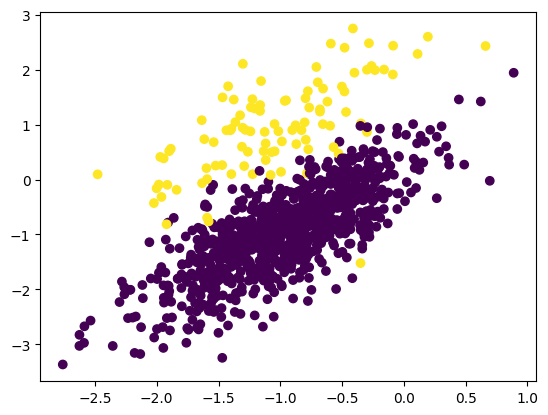

In [23]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'] , final_df['f2'] , c=final_df['target'])

In [24]:
from imblearn.over_sampling import SMOTE 


In [30]:
oversample = SMOTE()
x,y = oversample.fit_resample(final_df[['f1' , 'f2']] , final_df['target'])
df1=pd.DataFrame(x , columns=['f1' , 'f2'])
df2 = pd.DataFrame(y,columns=['target'])
oversample_df = pd.concat([df1,df2] , axis=1)

In [27]:
x.shape

(1800, 2)

In [28]:
y.shape

(1800,)

In [29]:
y[y==0]

0      0
1      0
2      0
4      0
5      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: target, Length: 900, dtype: int64

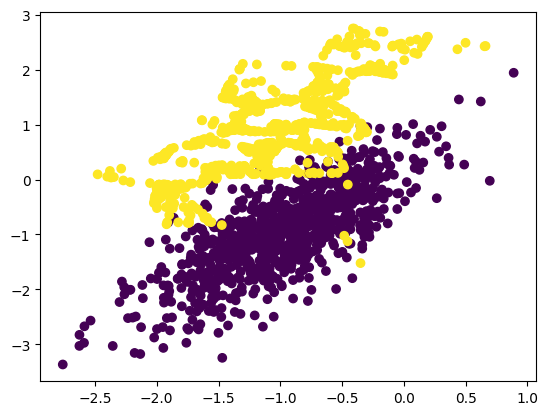

: 

In [ ]:
plt.scatter(oversample_df['f1'] , oversample_df['f2'] , c=oversample_df['target'])